In [1]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir()


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    failure_prob = dict()
    for folder in tqdm(folders):
        n_sum = int(folder.name.split('_')[0][1:])

        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        if n_sum in failure_prob:
            failure_prob[n_sum].append(P_ig)
        else:
            failure_prob[n_sum] = [P_ig, ]
    return failure_prob


data = dict(
    without_sprinkler=read_data(pathlib.Path(getcwd(), 'without_sprinkler')),
    with_sprinkler=read_data(pathlib.Path(getcwd(), 'with_sprinkler')),
)

100%|██████████| 40/40 [00:00<00:00, 1028.70it/s]


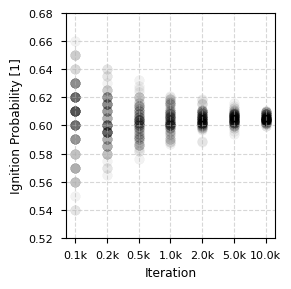

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(3, 3))
x_original = list(sorted(data['without_sprinkler'].keys()))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
for i, key in enumerate(x_original):
    values = data['without_sprinkler'][key]
    x_positions = [i + 1] * len(values)
    jittered_x = [x + np.random.uniform(-0.05, 0.05) for x in x_positions]
    ax.scatter(
        x_positions, values, alpha=0.05, s=50, label=str(key),
        # color=colors[i % len(colors)]
        color='k'
    )

ax.set_xlabel('Iteration')
ax.set_xticks(range(1, len(x_original) + 1))
ax.set_xticklabels(f'{i / 1000:.1f}k' for i in x_original)

ax.set_ylabel('Ignition Probability [1]')
ax.set_ylim(0.52, 0.68)

ax.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

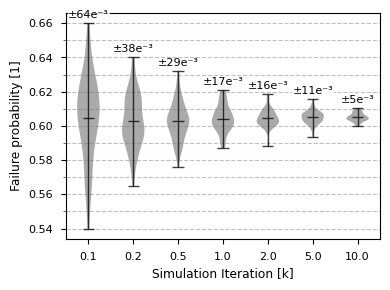

In [133]:
from matplotlib.ticker import AutoMinorLocator

# Create figure and axis using subplots
fig, ax = plt.subplots(figsize=(4, 3))

# Convert dictionary values to a list of arrays
x = list(sorted(data['without_sprinkler'].keys()))
violin_data = [data['without_sprinkler'][i] for i in x]

# Create violin plot
violin_parts = ax.violinplot(
    violin_data,
    showmeans=True,  # Show mean as a line
    showmedians=False,  # Don't show median line
    showextrema=True,  # Show whiskers
)

max_vals = [np.amax(vals) for vals in violin_data]
min_vals = [np.amin(vals) for vals in violin_data]
means = [np.mean(vals) for vals in violin_data]
deltas = [means[0] - mean for mean in means[1:]]  # Group A vs. rest
errors = [max(np.abs(max_vals[i]-means[i]), np.abs(min_vals[i]-means[i])) for i in range(len(violin_data))]
for i, error_ in enumerate(errors):
    ax.text(
        x=i+1,  # x-position (Group B starts at index 2)
        y=max_vals[i]+0.002,  # y-position (above the mean)
        s=f'±{error_*1000:.0f}e⁻³',  # delta value formatted
        ha='center',  # horizontal alignment
        va='bottom',
        fontsize=8,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='w', pad=0.1, lw=0.5)
    )

# Make all the violin statistics marks red:
for partname in ('cbars','cmins','cmaxes','cmeans'):
    vp = violin_parts[partname]
    vp.set_edgecolor('k')
    vp.set_linewidth(1)
    vp.set_alpha(0.75)

# Customize colors (optional)
for pc in violin_parts['bodies']:
    pc.set_facecolor('k')
    # pc.set_edgecolor('k')
    pc.set_alpha(0.333)
    # pc.set_color('red')
    # pc.set_linewidth(1)

# Set x-axis labels
ax.set_xticks(range(1, len(data['without_sprinkler']) + 1))
ax.set_xticklabels(f'{i/1000:.1f}' for i in x)

# Add labels and title
ax.set_xlabel('Simulation Iteration [k]')
ax.set_ylabel('Failure probability [1]')

ax.grid(axis='y', which='major', linestyle='--', alpha=0.5, color='gray')
ax.grid(axis='y', which='minor', linestyle='--', alpha=0.5, color='gray')
ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks per major tick
# ax.set_ylim(0.53, 0.67)
ax.set_xlim(0.5, len(violin_data)+0.5)

plt.tight_layout()
plt.show()

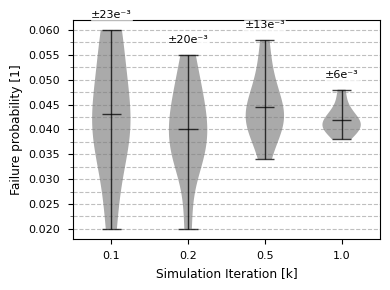

In [134]:
from matplotlib.ticker import AutoMinorLocator

# Create figure and axis using subplots
fig, ax = plt.subplots(figsize=(4, 3))

# Convert dictionary values to a list of arrays
x = list(sorted(data['with_sprinkler'].keys()))
violin_data = [data['with_sprinkler'][i] for i in x]

# Create violin plot
violin_parts = ax.violinplot(
    violin_data,
    showmeans=True,  # Show mean as a line
    showmedians=False,  # Don't show median line
    showextrema=True,  # Show whiskers
)

max_vals = [np.amax(vals) for vals in violin_data]
min_vals = [np.amin(vals) for vals in violin_data]
means = [np.mean(vals) for vals in violin_data]
deltas = [means[0] - mean for mean in means[1:]]  # Group A vs. rest
errors = [max(np.abs(max_vals[i]-means[i]), np.abs(min_vals[i]-means[i])) for i in range(len(violin_data))]
for i, error_ in enumerate(errors):
    ax.text(
        x=i+1,  # x-position (Group B starts at index 2)
        y=max_vals[i]+0.002,  # y-position (above the mean)
        s=f'±{error_*1000:.0f}e⁻³',  # delta value formatted
        ha='center',  # horizontal alignment
        va='bottom',
        fontsize=8,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='w', pad=0.1, lw=0.5)
    )

# Make all the violin statistics marks red:
for partname in ('cbars','cmins','cmaxes','cmeans'):
    vp = violin_parts[partname]
    vp.set_edgecolor('k')
    vp.set_linewidth(1)
    vp.set_alpha(0.75)

# Customize colors (optional)
for pc in violin_parts['bodies']:
    pc.set_facecolor('k')
    # pc.set_edgecolor('k')
    pc.set_alpha(0.333)
    # pc.set_color('red')
    # pc.set_linewidth(1)

# Set x-axis labels
ax.set_xticks(range(1, len(data['with_sprinkler']) + 1))
ax.set_xticklabels(f'{i/1000:.1f}' for i in x)

# Add labels and title
ax.set_xlabel('Simulation Iteration [k]')
ax.set_ylabel('Failure probability [1]')

ax.grid(axis='y', which='major', linestyle='--', alpha=0.5, color='gray')
ax.grid(axis='y', which='minor', linestyle='--', alpha=0.5, color='gray')
ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks per major tick
# ax.set_ylim(0.53, 0.67)
ax.set_xlim(0.5, len(violin_data)+0.5)

plt.tight_layout()
plt.show()